# CMO Marketing Audit
## Customer Personality Analysis | 2,229 Customers | 6 Campaigns

## Executive Summary

This audit reviews six marketing campaigns run across 2,229 customers to find where 
campaign effort is paying off and where it is being wasted.

The short answer: most of the return comes from one campaign and one type of customer, 
high income customers in small households. Campaign 2, and catalogs sent to low income 
and large households, deliver almost nothing.

### Key Findings

Four findings support this.

1. **Campaign performance splits sharply.** The final campaign converted at 14.8%, 
twice the 7.4% average. Campaign 2 converted at 1.3%, roughly six times below it. 
The rest sit near average.

2. **Conversion concentrates in high income, small households.** High income 
customers convert at 48.4% against 14.2% for low income. Single customers convert 
at 50.8% against 12.5% for the largest households. Age shows almost no variation.

3. **Wines and meat are both the revenue base and the responder signal.** They make 
up 77% of average spend, and responders outspend non-responders by 2.5x on wines and 
2.2x on meat, against roughly 1.6x everywhere else.

4. **Catalog only works for high income customers.** Catalog share rises from 8.7% 
of low income purchases to 29.5% of high income purchases, and falls from 28% to 13% 
as household size grows. Store leads in every segment.

### Recommended Reallocation

**Cut.** Campaign 2. Catalog distribution to low income customers and large households.

**Hold.** Campaigns 1, 3, 4 and 5, which perform near average.

**Double.** The final campaign's approach, as the clear template to replicate. 
Targeting of high income and one or two person households, who convert at three to 
four times the rate of the weakest segments. Offers led by wines and meat. Web for 
large families, who already make 40% of their purchases there.

### Audit Questions
1. Which campaigns delivered acceptable response rates, and which burned budget?
2. Which customer segments actually convert, and which are we overspending to reach?
3. Which product categories drive the most revenue, and are campaign responders the ones buying them?
4. Which channels does each segment actually buy through?
5. Given all this, what's the reallocation? What gets cut, what gets doubled?

### Dataset
Kaggle Customer Personality Analysis. Customer records from a retail company, 
2012 to 2014, covering demographics, spend across six product categories, purchase 
channels, and response to six marketing campaigns. 2,240 records, 2,229 after cleaning.

## 1. Setup & Initial Exploration
Loading the dataset and running initial checks to understand structure, data types, and missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv('/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## 2. Data Cleaning

Before analysis, the dataset requires several cleaning steps:
- Drop uninformative columns (Z_CostContact, Z_Revenue - constant values, no analytical value)
- Handle 24 missing income values
- Remove outliers (impossible birth years, extreme income, weird values)
- Fix data types (Dt_Customer → datetime)

In [4]:
df=df.drop(columns=["Z_CostContact", "Z_Revenue"])

In [5]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [6]:
# Remove outliers and invalid values
df = df[df["Year_Birth"] >= 1940]
df = df[df["Income"] != 666666] 
df = df[~df["Marital_Status"].isin(["Alone","Absurd","YOLO"])]

In [7]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

## 3. Feature Engineering
Creating derived columns to enable segmentation and campaign analysis.

In [8]:
df["Total_Spend"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [9]:
df["Total_Campaigns_Accepted"] = df["AcceptedCmp1"]+df["AcceptedCmp2"]+df["AcceptedCmp3"]+df["AcceptedCmp4"]+df["AcceptedCmp5"]+df["Response"]

In [10]:
df["Responder"] = (df["Total_Campaigns_Accepted"] > 0).astype(int)

In [11]:
# Using 2014 as reference year (most recent enrollment year in dataset)
df["Age"] = 2014 - df["Year_Birth"]

In [12]:
# Tenure calculated as days from enrollment to end of data collection period (2014-12-31)
df["Tenure"] = (pd.Timestamp("2014-12-31") - df["Dt_Customer"]).dt.days

In [13]:
df["Family_Size"] = df["Marital_Status"].isin(["Together","Married"]).astype(int) + df["Kidhome"] + df["Teenhome"]

In [14]:
df["Income_Group"] = pd.cut(df["Income"], bins=[0,35000,68000,163000], labels=["Low","Mid","High"])

In [15]:
df["Age_Group"] = pd.cut(df["Age"], bins=[0, 37, 55, 74], labels=["Young", "Middle", "Senior"])

## 4. EDA & Analysis
Computing metrics and visualizing findings to answer each audit question.

### Q1: Which campaigns delivered acceptable response rates, and which burned budget?

Response rate (% of customers who accepted) is the primary measure of campaign effectiveness. Since cost data is unavailable, response rate serves as our proxy for budget efficiency.

In [16]:
# Response rate per campaign - identifies which campaigns converted and which underperformed
campaign_response = df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].mean() * 100
campaign_response_sorted = campaign_response.sort_values()

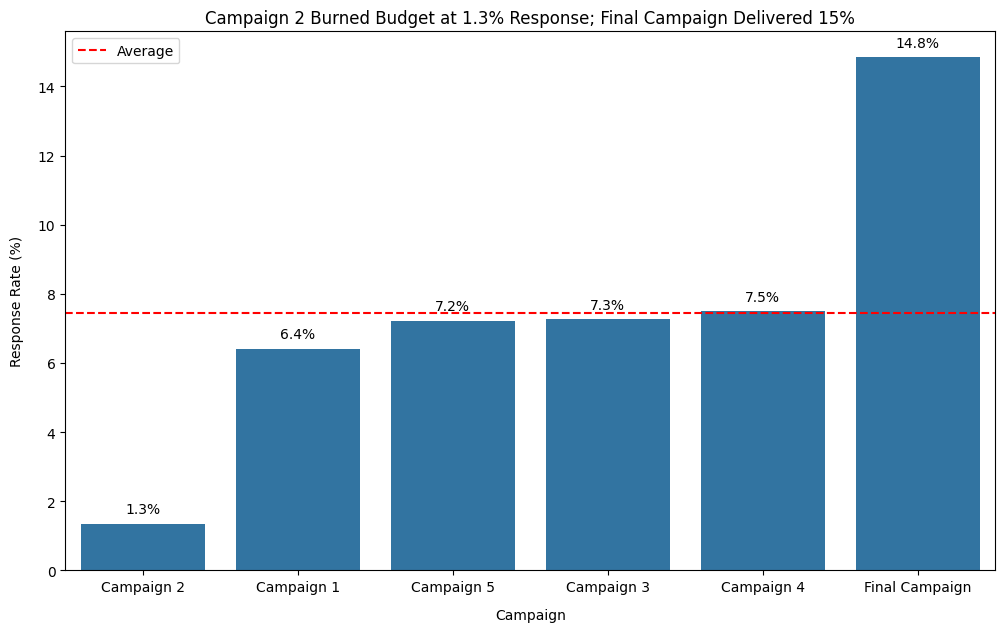

In [17]:
plt.figure(figsize=(12,7))
sns.barplot(x=campaign_response_sorted.index, y=campaign_response_sorted.values)
plt.title("Campaign 2 Burned Budget at 1.3% Response; Final Campaign Delivered 15%")
plt.xlabel("Campaign", labelpad=10)
plt.ylabel("Response Rate (%)", labelpad=10)
plt.axhline(y=campaign_response.mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.xticks(ticks=range(6), labels=["Campaign 2", "Campaign 1", "Campaign 5", "Campaign 3", "Campaign 4", "Final Campaign"])
for i, v in enumerate(campaign_response_sorted.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.show()

The final campaign stands out with a 14.8% response rate, twice the average of 7.4%. Campaigns 3, 4, and 5 all performed close 
to average, suggesting they are working as expected. Campaign 1 
slightly underperformed at 6.4%, but Campaign 2 is the real concern 
at just 1.3% - roughly 6x below average and the clearest candidate 
for budget reallocation.

### Q2: Which customer segments actually convert - and which are we overspending to reach?

Measuring response rate across income, age, and family size segments to identify which customer profiles drive campaign conversion.

In [18]:
# Response rate by income group - identifies which wealth segment converts most
response_by_income = df.groupby("Income_Group")["Responder"].mean()*100

/tmp/ipykernel_16/243812659.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_by_income = df.groupby("Income_Group")["Responder"].mean()*100


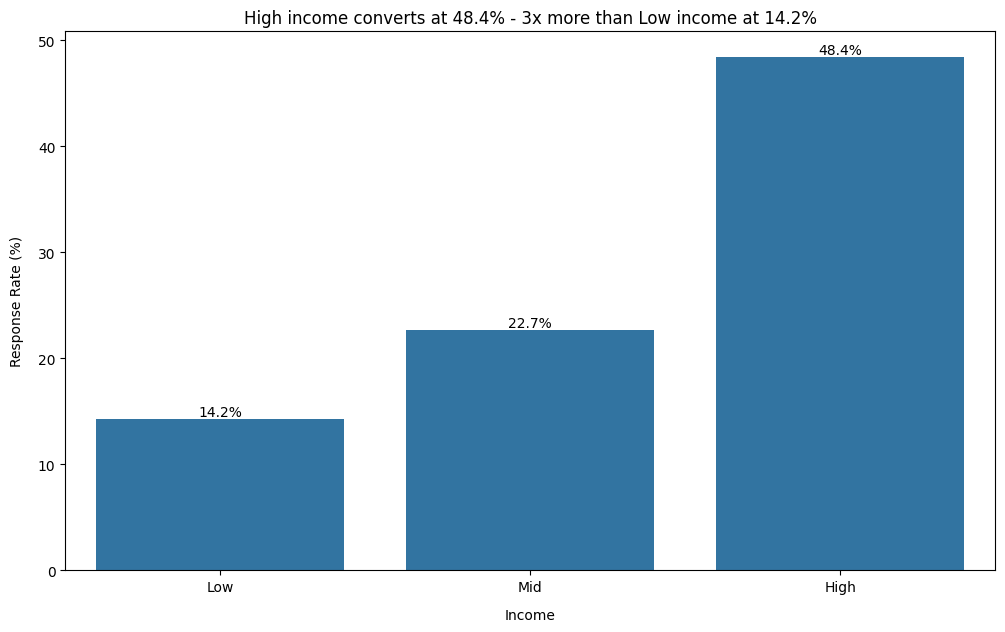

In [19]:
plt.figure(figsize=(12,7))
sns.barplot(x=response_by_income.index, y =response_by_income.values)
plt.title("High income converts at 48.4% - 3x more than Low income at 14.2%")
plt.xlabel("Income", labelpad=10)
plt.ylabel("Response Rate (%)", labelpad=10)
for i, v in enumerate(response_by_income.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.show()

In [20]:
# Among responders only — avg campaigns accepted per income group (measures engagement depth)
df[df["Responder"]==1].groupby("Income_Group")["Total_Campaigns_Accepted"].mean()

/tmp/ipykernel_16/808403559.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["Responder"]==1].groupby("Income_Group")["Total_Campaigns_Accepted"].mean()


Income_Group
Low     1.243590
Mid     1.332016
High    2.043796
Name: Total_Campaigns_Accepted, dtype: float64

High income customers convert at 48.4%, more than 3x the low income rate of 14.2%, and accept twice as many campaigns on average (2.0 vs 1.2). They are the most valuable segment to target - and the clearest case for reallocation away from low income.

In [21]:
# Response rate by age group - identifies which age segment converts most
response_by_age = df.groupby("Age_Group")["Responder"].mean()*100

/tmp/ipykernel_16/2949921091.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_by_age = df.groupby("Age_Group")["Responder"].mean()*100


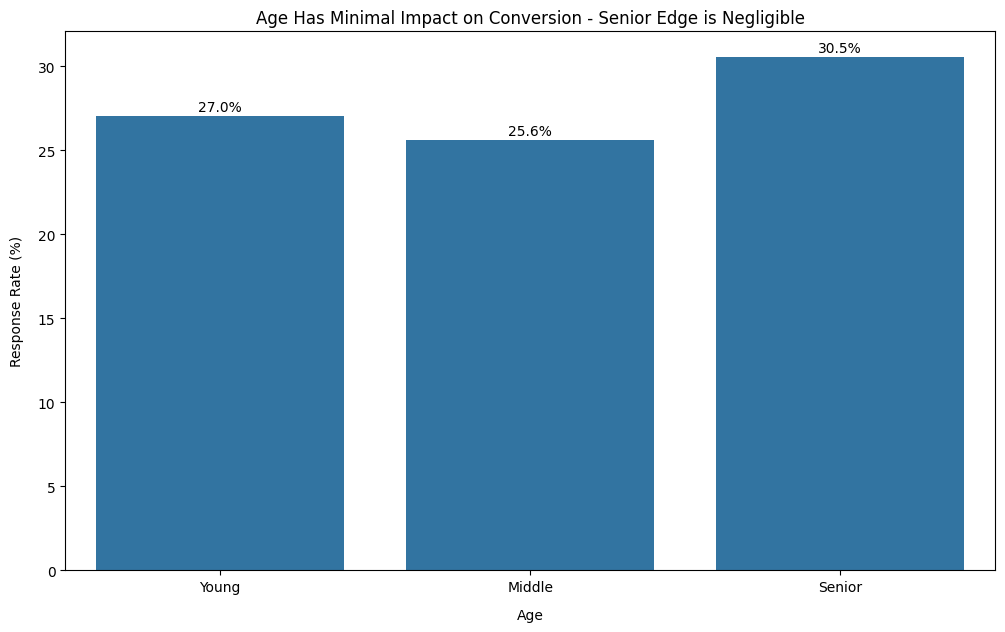

In [22]:
plt.figure(figsize=(12,7))
sns.barplot(x=response_by_age.index, y=response_by_age.values)
plt.title("Age Has Minimal Impact on Conversion - Senior Edge is Negligible")
plt.xlabel("Age", labelpad=10)
plt.ylabel("Response Rate (%)", labelpad=10)
for i, v in enumerate(response_by_age.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.show()

In [23]:
# Among responders only — avg campaigns accepted per age group (measures engagement depth)
df[df["Responder"]==1].groupby("Age_Group")["Total_Campaigns_Accepted"].mean()

/tmp/ipykernel_16/2237302736.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["Responder"]==1].groupby("Age_Group")["Total_Campaigns_Accepted"].mean()


Age_Group
Young     1.840491
Middle    1.550877
Senior    1.605096
Name: Total_Campaigns_Accepted, dtype: float64

Response rates across age groups are narrow, with Seniors leading at 30.5% and Young and Middle segments following closely at 27.0% and 25.6%. Among responders, Young customers accept slightly more campaigns on average (1.84 vs 1.55 for Middle), though the gap is not significant. Unlike income, age is not a meaningful targeting variable and should not drive campaign segmentation decisions.

In [24]:
# Response rate by family size - identifies whether household size affects conversion
response_by_family_size = df.groupby("Family_Size")["Responder"].mean()*100

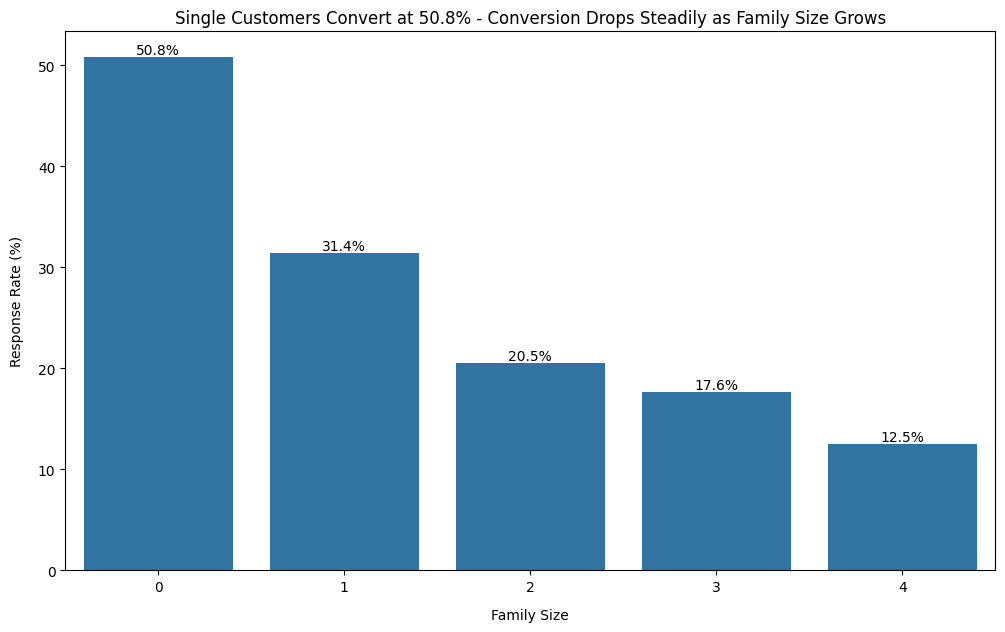

In [25]:
plt.figure(figsize=(12,7))
sns.barplot(x=response_by_family_size.index, y=response_by_family_size.values)
plt.title("Single Customers Convert at 50.8% - Conversion Drops Steadily as Family Size Grows")
plt.xlabel("Family Size", labelpad=10)
plt.ylabel("Response Rate (%)", labelpad=10)
for i, v in enumerate(response_by_family_size.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.show()

In [26]:
df[df["Responder"] == 1].groupby("Family_Size")["Total_Campaigns_Accepted"].mean()

Family_Size
0    1.937500
1    1.743697
2    1.428571
3    1.245283
4    1.250000
Name: Total_Campaigns_Accepted, dtype: float64

Single customers without children convert at 50.8%, and conversion declines steadily as family size grows, falling to 12.5% for the largest households. The same pattern holds for engagement depth among responders. Small households are the campaign sweet spot; large families are not worth the spend.

### Q3: Which product categories drive the most revenue - and are campaign responders the ones buying them?

Measuring total spend per product category and comparing responder vs non-responder spend to assess whether campaigns are reaching the right buyers.

In [27]:
# Average spend per product category across all customers
mean_spend = df[["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].mean()
mean_spend_sorted = mean_spend.sort_values(ascending = False)

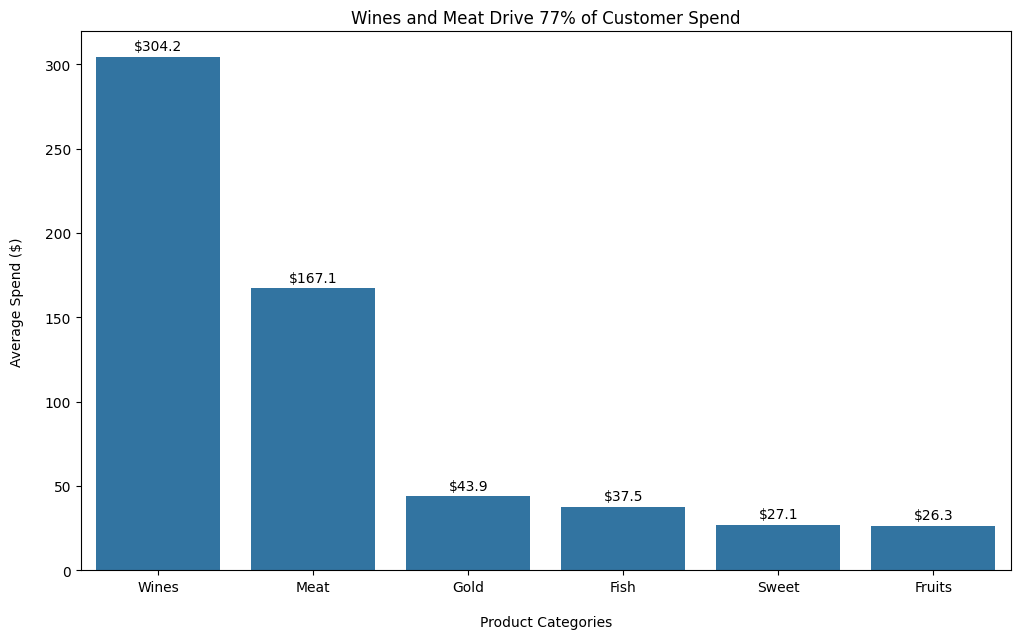

In [28]:
plt.figure(figsize=(12,7))
sns.barplot(x=mean_spend_sorted.index, y=mean_spend_sorted.values)
plt.title("Wines and Meat Drive 77% of Customer Spend") 
plt.xlabel("Product Categories", labelpad=15)
plt.ylabel("Average Spend ($)", labelpad=15)
plt.xticks(ticks = range(6), labels = ["Wines","Meat","Gold","Fish","Sweet","Fruits"])
for i, v in enumerate(mean_spend_sorted.values):
    plt.text(i, v + 4, f"${v:.1f}", ha='center')
plt.show()

In [29]:
# Average spend per category split by responders vs non-responders
spend_by_responder = df.groupby("Responder")[["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].mean()

In [30]:
# Spend ratio: responders vs non-responders per category
spend_ratio = spend_by_responder.loc[1] / spend_by_responder.loc[0]
spend_ratio.round(2)

MntWines            2.48
MntFruits           1.57
MntMeatProducts     2.21
MntFishProducts     1.62
MntSweetProducts    1.66
MntGoldProds        1.58
dtype: float64

In [31]:
# Reshape to long format for grouped bar chart - responders vs non-responders per category
spend_melted = spend_by_responder.reset_index().melt(id_vars='Responder', var_name='Category', value_name='Spend')
spend_melted['Responder'] = spend_melted['Responder'].replace({0: 'Non-Responder', 1: 'Responder'})

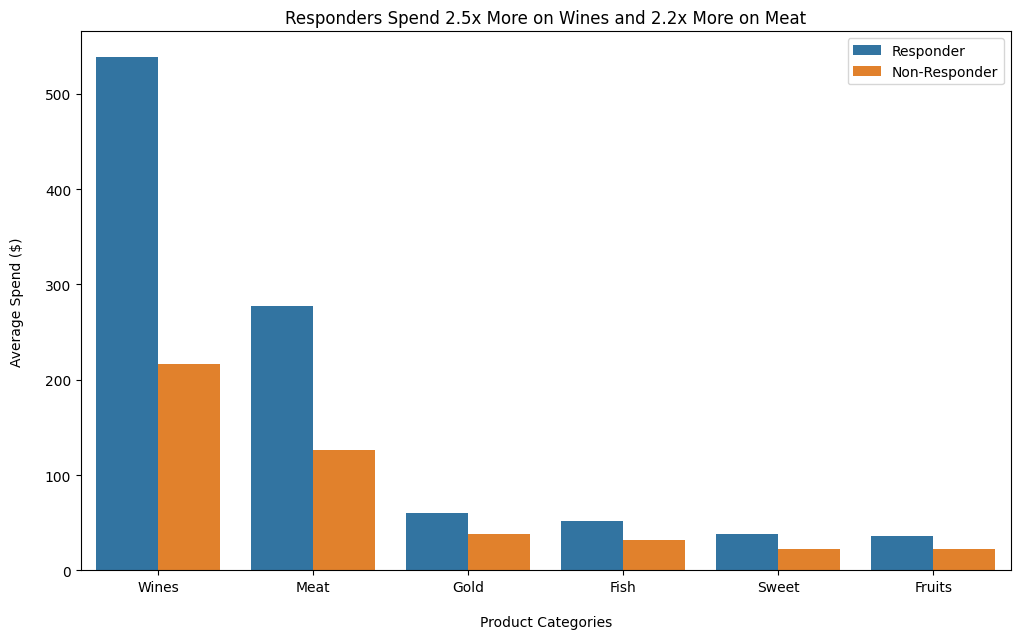

In [32]:
# Order categories by descending spend for consistency
category_order = ["MntWines", "MntMeatProducts", "MntGoldProds", "MntFishProducts", "MntSweetProducts", "MntFruits"]

plt.figure(figsize=(12,7))
sns.barplot(x="Category", y="Spend", hue="Responder", data=spend_melted, order=category_order, hue_order=['Responder', 'Non-Responder'])
plt.title("Responders Spend 2.5x More on Wines and 2.2x More on Meat") 
plt.xlabel("Product Categories", labelpad=15)
plt.ylabel("Average Spend ($)", labelpad=15)
plt.legend(title='')
plt.xticks(ticks = range(6), labels = ["Wines","Meat","Gold","Fish","Sweet","Fruits"])
plt.show()

Wines and Meat account for 77% of average customer spend. Campaign responders spend 2.5x more on Wines (`$539` vs `$217`) and 2.2x more on Meat (`$278` vs `$126`) than non-responders, suggesting campaigns are reaching the higher-value buyers in the most profitable categories. The responder premium concentrates in Wines (2.5x) and Meat (2.2x), against roughly 1.6x across all other categories, confirming the lift is not uniform but sits in the two highest-revenue products.

### Q4: Which channels does each segment actually buy through?

Comparing channel share across income, family size, and age segments to identify how each group prefers to buy.

In [33]:
# Purchase share per channel by income segment - identifies where each group shops
channel_by_income = df.groupby("Income_Group")[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].mean()
channel_by_income_pct = channel_by_income.div(channel_by_income.sum(axis=1), axis=0) * 100

/tmp/ipykernel_16/1741433821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_by_income = df.groupby("Income_Group")[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].mean()


In [34]:
# Reshape to long format for grouped bar chart - channel preference by income segment
channel_by_income_melted = channel_by_income_pct.reset_index().melt(id_vars = "Income_Group", var_name = "Channel", value_name="Share")
channel_by_income_melted["Channel"] = channel_by_income_melted["Channel"].replace({"NumWebPurchases" : "Web", "NumCatalogPurchases" : "Catalog", "NumStorePurchases" : "Store"})

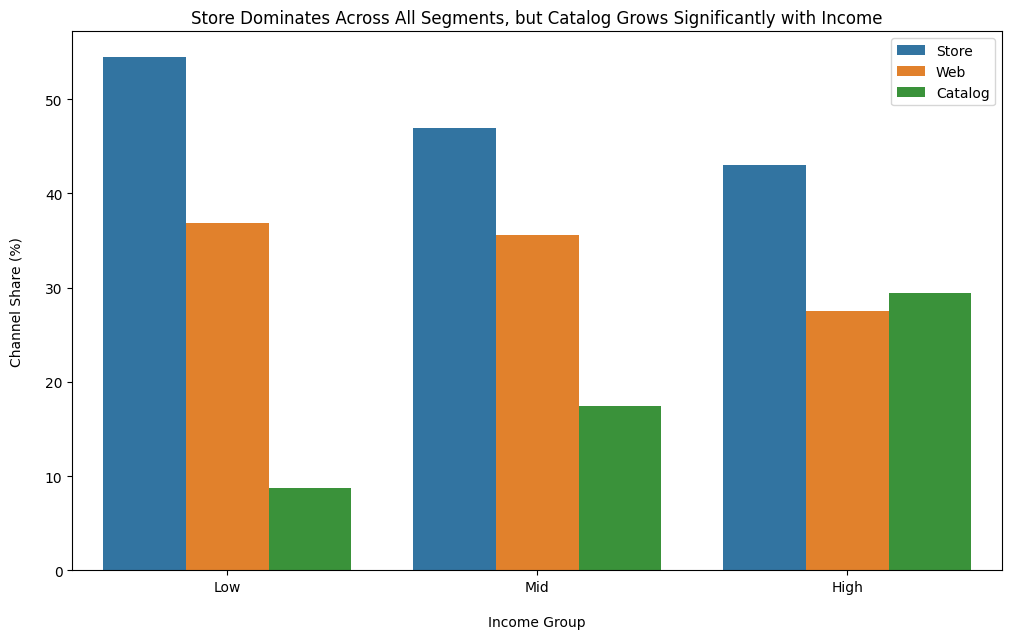

In [35]:
plt.figure(figsize=(12,7))
sns.barplot(x="Income_Group", y="Share", hue="Channel", data=channel_by_income_melted, hue_order=["Store","Web","Catalog"])
plt.title("Store Dominates Across All Segments, but Catalog Grows Significantly with Income")
plt.xlabel("Income Group", labelpad=15)
plt.ylabel("Channel Share (%)", labelpad=15)
plt.legend(title='')
plt.show()

Store is the dominant channel across all income groups, accounting for 54% of Low income purchases and 43% of High income purchases. Catalog usage grows significantly with income, rising from just 8.7% among Low income customers to 29.5% among High income customers, nearly matching web at 27.5%. Low income customers buy almost entirely through store and web, so catalog distribution to that segment reaches an audience that rarely orders from it.

In [36]:
# Purchase share per channel by age segment - identifies where each group shops
channel_by_age = df.groupby("Age_Group")[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].mean()
channel_by_age_pct = channel_by_age.div(channel_by_age.sum(axis=1), axis=0) * 100

/tmp/ipykernel_16/2511804288.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_by_age = df.groupby("Age_Group")[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].mean()


In [37]:
# Reshape to long format for grouped bar chart - channel preference by age segment
channel_by_age_melted = channel_by_age_pct.reset_index().melt(id_vars = "Age_Group", var_name = "Channel", value_name="Share")
channel_by_age_melted["Channel"] = channel_by_age_melted["Channel"].replace({"NumWebPurchases" : "Web", "NumCatalogPurchases" : "Catalog", "NumStorePurchases" : "Store"})

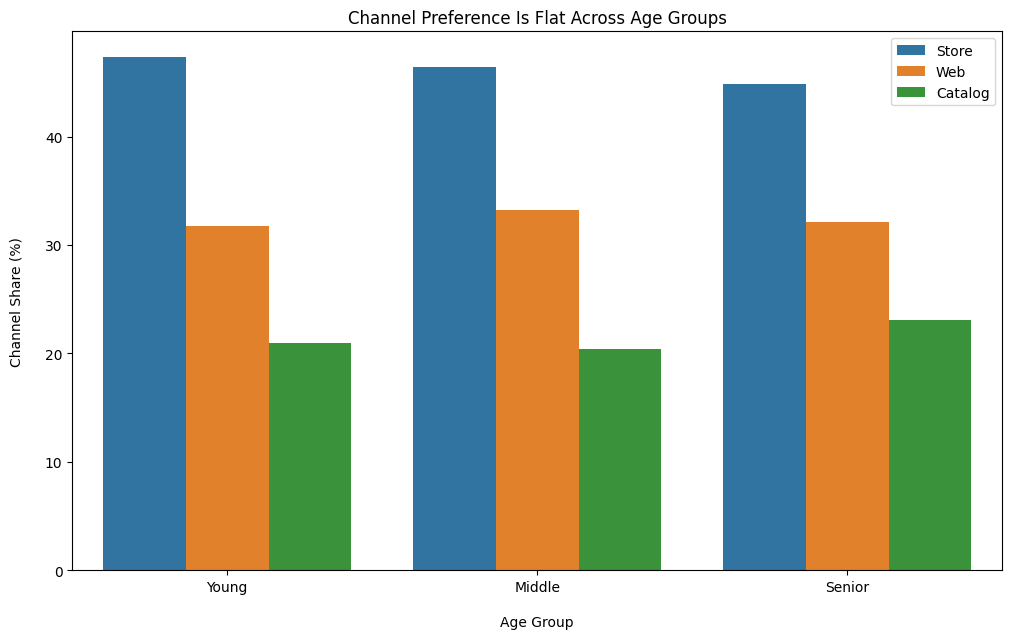

In [38]:
plt.figure(figsize=(12,7))
sns.barplot(x="Age_Group", y="Share", hue="Channel", data=channel_by_age_melted, hue_order=["Store","Web","Catalog"])
plt.title("Channel Preference Is Flat Across Age Groups")
plt.xlabel("Age Group", labelpad=15)
plt.ylabel("Channel Share (%)", labelpad=15)
plt.legend(title='')
plt.show()

Channel preference is essentially identical across age groups, with Store at 45-47%, Web at 32-33% and Catalog at 20-23% in every group. Age does not predict how customers buy and should not drive channel decisions.

In [39]:
# Purchase share per channel by family size segment - identifies where each group shops
channel_by_family = df.groupby("Family_Size")[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].mean()
channel_by_family_pct = channel_by_family.div(channel_by_family.sum(axis=1), axis=0) * 100

In [40]:
# Reshape to long format for grouped bar chart - channel preference by family size segment
channel_by_family_melted = channel_by_family_pct.reset_index().melt(id_vars = "Family_Size", var_name = "Channel", value_name="Share")
channel_by_family_melted["Channel"] = channel_by_family_melted["Channel"].replace({"NumWebPurchases" : "Web", "NumCatalogPurchases" : "Catalog", "NumStorePurchases" : "Store"})

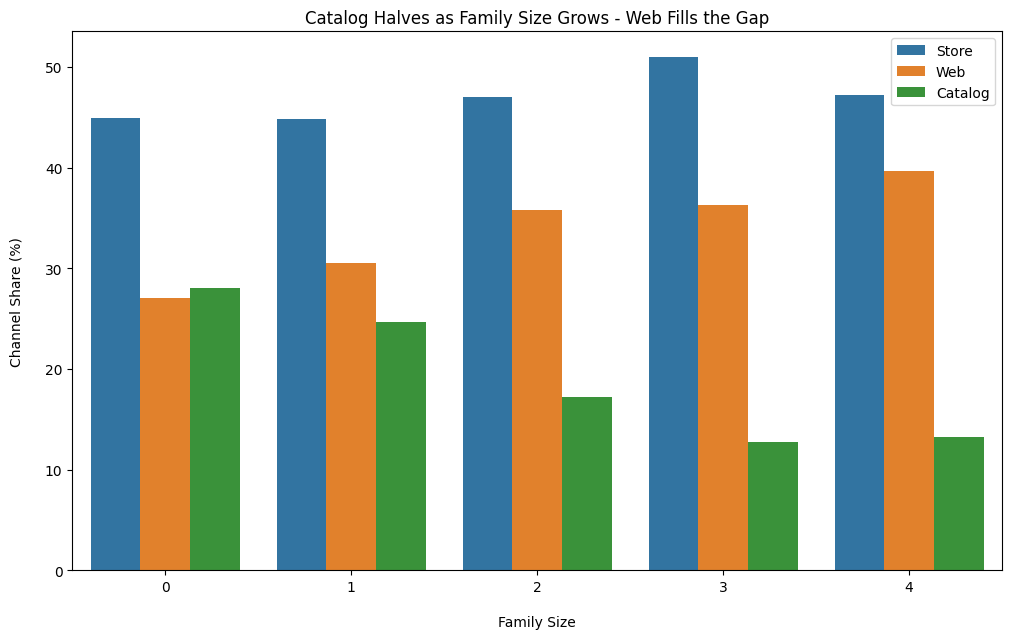

In [41]:
plt.figure(figsize=(12,7))
sns.barplot(x="Family_Size", y="Share", hue="Channel", data=channel_by_family_melted, hue_order=["Store","Web","Catalog"])
plt.title("Catalog Halves as Family Size Grows - Web Fills the Gap")
plt.xlabel("Family Size", labelpad=15)
plt.ylabel("Channel Share (%)", labelpad=15)
plt.legend(title='')
plt.show()

As family size grows, catalog share drops from 28% to 13% while web share rises from 27% to 40%. Store remains the dominant channel across all household sizes at roughly 45-51%. Catalog distribution to large families is largely wasted - web is where they buy.

## 5. Recommendation

### Q5: Given all this, what's the reallocation? What gets cut, what gets doubled?

The findings point to a narrow profile. Conversion sits with high income, small 
households. Revenue sits in wines and meat. Catalog works for high income customers 
and barely reaches anyone else. The reallocation follows from that.

**Cut.** Campaign 2, at 1.3% against a 7.4% average. Catalog distribution to low 
income customers (8.7% of their purchases) and to the largest households (13%).

**Hold.** Campaigns 1, 3, 4 and 5. They sit close enough to average that moving them 
either way is not supported by this data.

**Double.** The final campaign's approach, which converted at 14.8% and is the clear 
template to replicate. Targeting of high income and one or two person households, who 
convert at three to four times the rate of the weakest segments. Offers led by wines 
and meat, where the responder premium is 2.2x to 2.5x against roughly 1.6x elsewhere. 
Web for large families, who already make 40% of their purchases there.

Age should be dropped as a targeting variable. Conversion and channel preference are 
both flat across age groups.

## 6. Limitations

- **No campaign cost data.** The reallocation is based on response rate, not return 
on spend. A low cost campaign with a modest response rate could still be worth keeping.
- **No targeting data.** Response rates are measured across all customers, which 
assumes every customer received every campaign. If campaigns were sent to different 
groups, their rates are not directly comparable.
- **Channel data counts purchases, not spend.** Channel share reflects the number 
of orders through each channel, not their value. A channel with fewer but larger 
orders may matter more to revenue than its share suggests.

## 7. Next Steps

- A/B test wine and meat led offers to confirm whether they lift response, rather 
than simply appealing to customers who already buy them.
- Test the key segment differences for statistical significance.
- Cluster customers across several variables at once to find segments that single 
variable cuts miss.